### Prosjektoppgave_PY1010

#### Support dahsboard for MORSE

##### Laget av Mari Nesse Bolstad 2025 04 10

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [31]:
# Del a) Les inn data

data = pd.read_excel("C:\\Users\\maboa076\\Desktop\\support_uke_24.xlsx")

In [36]:
# Hente ut kolonner og lagre som array

u_dag = np.array(df['Ukedag'])
kl_slett = np.array(df['Klokkeslett'])
varighet = np.array(df['Varighet'])
score = np.array(df['Tilfredshet'])

In [55]:
#Del b) Henvendelser per ukedag

df['Ukedag'].value_counts()

Ukedag
Mandag     51
Onsdag     45
Tirsdag    44
Fredag     42
Torsdag    35
Name: count, dtype: int64

Text(0, 0.5, 'Antall henvendelser')

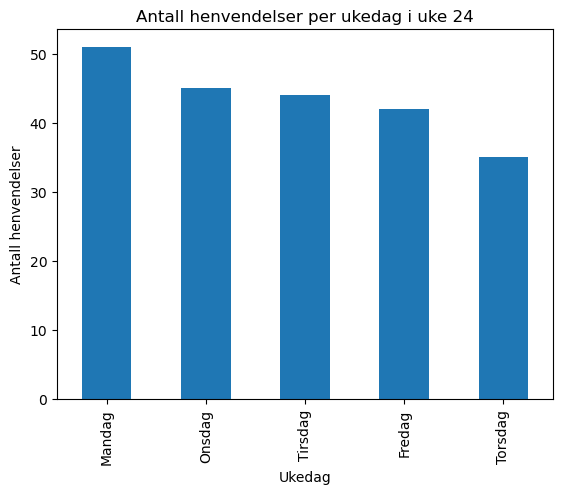

In [57]:
#Del b) Henvendelser per ukedag visualisert i stolpediagram

df['Ukedag'].value_counts().plot(kind='bar')

plt.title('Antall henvendelser per ukedag i uke 24')
plt.xlabel('Ukedag')
plt.ylabel('Antall henvendelser')


In [58]:
# Del c) Minste og lengste samtaletid

min_tid = min(varighet)
max_tid = max(varighet)
print(f"Minste samtaletid: {min_tid} minutter")
print(f"Lengste samtaletid: {max_tid} minutter")

Minste samtaletid: 00:00:59 minutter
Lengste samtaletid: 00:11:28 minutter


In [103]:
# Del d) Gjennomsnittlig samtaletid

df['Varighet'].dtype

df['Varighet'] = pd.to_timedelta(df['Varighet'])

gjennomsnitt = df['Varighet'].mean()

print(f"Gjennomsnittlig samtaletid er: {gjennomsnitt.total_seconds() / 60:.2f} minutter")

Gjennomsnittlig samtaletid er: 6.67 minutter


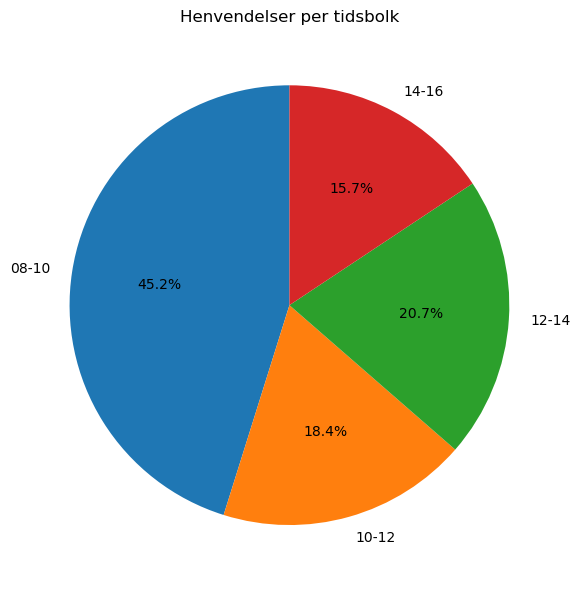

In [66]:
# Del e) Henvendelser per tidsbolk (kakediagram)
# Først konverterer vi klokkeslett til time-tall
def hent_bolk(klokkeslett):
    time = int(str(klokkeslett).split(":")[0])
    if 8 <= time < 10:
        return "08-10"
    elif 10 <= time < 12:
        return "10-12"
    elif 12 <= time < 14:
        return "12-14"
    elif 14 <= time < 16:
        return "14-16"
    else:
        return "Utenfor vakt"

bolker = ['08-10', '10-12', '12-14', '14-16']
bolk_teller = {bolk: 0 for bolk in bolker}

for tid in kl_slett:
    bolk = hent_bolk(tid)
    if bolk in bolk_teller:
        bolk_teller[bolk] += 1

# Tegn kakediagram
plt.figure(figsize=(6,6))
plt.pie(bolk_teller.values(), labels=bolk_teller.keys(), autopct='%1.1f%%', startangle=90)
plt.title("Henvendelser per tidsbolk")
plt.tight_layout()
plt.show()

In [71]:
# Del f) NPS-utregning
gyldige_scores = [s for s in score if not pd.isna(s)]

negative = sum(1 for s in gyldige_scores if 1 <= s <= 6)
noytrale = sum(1 for s in gyldige_scores if 7 <= s <= 8)
positive = sum(1 for s in gyldige_scores if 9 <= s <= 10)
totalt = len(gyldige_scores)

nps = ((positive / totalt) - (negative / totalt)) * 100

print(f"NPS (Net Promoter Score): {nps:.1f}")

NPS (Net Promoter Score): 41.9
